In [6]:
import numpy as np
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from scipy import integrate
import scipy

from scipy.interpolate import interp1d
from scipy.integrate import odeint

In [7]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', family='serif')
plt.rc('font', size='22')
#plt.rcParams['figure.dpi'] = 150
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['xtick.minor.width'] = 1.5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['ytick.minor.width'] = 1.5

# compute cosmology

In [8]:
#import and define cosmlogy in class
from classy import Class

#Start by specifying the cosmology  - planck best fit
h = 0.6766
Omega_b = 0.02242/h**2
Omega_cdm = 0.11933/h**2
Omega_m = Omega_cdm+Omega_b
A_s = 2.105e-9 
n_s = 0.9665

#Create a params dictionary
#Need to specify the max wavenumber
k_max = 10 #UNITS: 1/Mpc # is also set to 10 later
params = {'output':'mPk,mTk',
             'non linear':'halofit',
             'Omega_b':Omega_b,
             'Omega_cdm':Omega_cdm,#Omega_m-Omega_b,#
             'h':h,
             'n_s':n_s,
             'A_s':A_s,#'n_s':n_s,'sigma8':0.828,#
             'P_k_max_1/Mpc':k_max,
             'z_max_pk':10. #Default value is 10
}

#Initialize the cosmology and compute everything
cosmo = Class()
cosmo.set(params)
cosmo.compute()

# define cosmological parameters and biases etc

In [9]:
class CosmologicalFunctions:
    def __init__(self,cosmo,survey='EUCLID'):
        """
            take in Class and spit out stuff and create bunch of functions needed to compute bispectrum
            i.e. all bias functions and other functions of cosmology (f,D,K,C etc)
        """
        self.cosmo = cosmo
        baLCDM = cosmo.get_background()

        f_cl = baLCDM['gr.fac. f']
        D_cl = baLCDM['gr.fac. D']
        z_cl = baLCDM['z']
        H_cl = baLCDM['H [1/Mpc]']
        xi_cl = baLCDM['comov. dist.']
        t_cl = baLCDM['conf. time [Mpc]']
        
        self.z_cl = z_cl#save for later
        self.Om_0 = cosmo.get_current_derived_parameters(['Omega_m'])['Omega_m']
        self.h = cosmo.get_current_derived_parameters(['h'])['h']
        
        #define functions and add in h
        self.H_c = interp1d(z_cl,H_cl*(1/(1+z_cl))/self.h,kind='cubic') # now in h/Mpc!
        self.dH_c = interp1d(z_cl,np.gradient(H_cl*(1/(1+z_cl))/self.h,z_cl),kind='cubic') # derivative wrt z
        self.ddH_c = interp1d(z_cl,np.gradient(self.dH_c(z_cl),z_cl),kind='cubic') # second derivative wrt z
        self.comoving_dist = interp1d(z_cl,xi_cl*self.h,kind='cubic') # just use class background as quick
        self.d_to_z = interp1d(xi_cl*self.h,z_cl,kind='cubic') # useful to map other way
        self.f_intp = interp1d(z_cl,f_cl,kind='cubic')#get f #omega_mz = Omega_m *(1+zt)**3 /(Omega_m *(1+zt)**3 + Omega_l)
        self.D_intp = interp1d(z_cl,D_cl,kind='cubic')
        self.dD_dz = interp1d(z_cl,np.gradient(D_cl,z_cl),kind='cubic')
        self.conf_time = interp1d(z_cl,self.h*t_cl,kind='cubic')#convert between the two
        #misc
        self.c = 2.99792*10**5 #km/s
        self.H0 = 100/self.c #[h/Mpc]
        self.Om = lambda xx: self.Om_0 * (self.H0**2 / self.H_c(xx)**2) * (1+xx)
        
        #define bias stuff
        if survey=='EUCLID':
            self.b_1  =  lambda xx: 0.9 + 0.4*xx
        elif survey=='DESI':
            self.b_1 =  lambda xx: 1.34/self.D_intp(xx)
        else:
            self.b_1  =  lambda xx: 0.9 + 0.4*xx#lambda xx: 0.9 + 0.4*xx
            
        self.g_2 = lambda xx: -(2/7)*(self.b_1(xx)-1)# 0.524-0.547*self.b_1(xx)+0.046*self.b_1(xx)**2#
        self.b_2 = lambda xx: 0.412 - 2.143*self.b_1(xx) +0.929*self.b_1(xx)**2 + 0.008*self.b_1(xx)**3 + 4/3 * self.g_2(xx)#-0.1*np.sqrt(1+xx)#
        
        self.z_samps = np.linspace(0.05, 10, 10000)#defined over appropiate range for numerical derivs
        
        #get derivs of these redshift dependent functions
        func_deriv_list = self.lnd_derivatives([self.b_1,self.b_2,self.g_2,self.f_intp,self.D_intp])
        self.b1_d,self.b2_d,self.g2_d,self.f_d,self.D_d = func_deriv_list
        func_second_deriv_list = self.lnd_derivatives(func_deriv_list)
        self.b1_dd,self.b2_dd,self.g2_dd,self.f_dd,self.D_dd = func_second_deriv_list
        
        if survey=='EUCLID':
            self.z_survey = np.linspace(0.9,1.8) 
            self.be_survey= lambda xx: -7.29 + 0.470*xx + 1.17*xx**2 - 0.290*xx**3
            self.Q_survey = lambda xx:0.583 + 2.02*xx - 0.568*xx**2 + 0.0411*xx**3
        elif survey=='DESI':
            self.z_survey = np.linspace(0.05,0.6) 
            self.be_survey= lambda xx: -2.25 - 4.02*xx + 0.318*xx**2 - 14.6*xx**3
            self.Q_survey = lambda xx: 0.282 + 2.36*xx + 2.27*xx**2 + 11.1*xx**3
        else:
            self.z_survey = np.linspace(0.9,1.8) 
            self.be_survey = lambda xx: 0*xx
            self.Q_survey = lambda xx:  0*xx #+ 2/5
            
    def get_class_powerspectrum(self,kk,zz): #h are needed to convert to 1/Mpc for k then convert pk back to (Mpc/h)^3
        return np.array([self.cosmo.pk_lin(ki, zz) for ki in kk*self.h])*h**3

    def get_pkinfo_z(self,k,z):
        Plin = self.get_class_powerspectrum(k,0)#just always get present day power spectrum
        Pk = interp1d(k,Plin)#get linear power spectrum
        self.Pk = Pk
        Pk_d = interp1d(k,np.gradient(Plin,k))
        Pk_dd = interp1d(k,np.gradient(Pk_d(k),k))
        return Pk,Pk_d,Pk_dd
    
    def Pk_phi(self,k,cosmo=cosmo, k0=0.05, units=True):
        """Power spectrum of the Bardeen potential Phi in the matter-dominated era - k in units of h/Mpc.
        """
        k_pivot = k0/h
        resp = (9.0/25.0) * cosmo.get_current_derived_parameters(['A_s'])['A_s'] * (k/k_pivot)**(cosmo.get_current_derived_parameters(['n_s'])['n_s'] - 1.0)

        if units:
            resp *= 2*np.pi**2.0/k**3.0    #[Mpc/h]^3

        return resp

    def M(self,k, z):
        """The scaling factor between the primordial scalar power spectrum and the late-time matter power spectrum
        """
        return np.sqrt(self.D_intp(z)**2 *self.Pk(k) / self.Pk_phi(k) )

    def solve_second_order_KC(self):
        c = 2.99792*10**5 #km/s
        def F_func(u,zz): # so variables are F and H and D
            f,fd = u # unpack u vector
            D_zz = self.D_intp(zz)
            return [fd,(-self.H_c(zz)*self.dH_c(zz)*(1+zz)**2 *fd + ((3*(self.H0)**2 * self.Om_0 *(1+zz))/(2))*(f+D_zz**2))/(self.H_c(zz)**2 *(1+zz)**2)]
        
        odeint_zz = np.linspace(20,0.05,int(1e+5))# so z=20 should be pretty much matter dominated

        #set initial params for F
        F0 = [(3/7)*self.D_intp(odeint_zz[0])**2,(3/7)*2*self.D_intp(odeint_zz[0])*self.dD_dz(odeint_zz[0])]
        sol1 = odeint(F_func,F0,odeint_zz)
        K = (sol1[:,0]/self.D_intp(odeint_zz)**2)
        C = sol1[:,1]/(2*self.D_intp(odeint_zz)*self.dD_dz(odeint_zz))
        self.K_intp = interp1d(odeint_zz,K,kind='cubic')
        self.C_intp = interp1d(odeint_zz,C,kind='cubic')
    
    def lnd_derivatives(self,functions_to_differentiate,z_range= [0]):
        """
            calculates derivatives of a list of functions wrt log comoving dist numerically
        """
        if len(z_range) == 1:
            z_range= self.z_samps

        # Store first derivatives in a list
        function_derivatives = []

        for func in functions_to_differentiate:
            # Calculate numerical derivatives of the function with respect to ln(d)
            derivative_func = interp1d(z_range, np.gradient(func(z_range), np.log(self.comoving_dist(z_range))))
            function_derivatives.append(derivative_func)

        return function_derivatives


    def get_params(self,k1,k2,theta,zz):
        """
            return arrays of redshift and k dependent parameters
        """
        self.solve_second_order_KC()#get K and C
        
        k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))#get k3 from triangle condition
        k3 = np.where(k3==0,1e-3,k3)
        
        k = np.logspace(-5, np.log10(k_max), num=1000)
        Pk,Pk_d,Pk_dd = self.get_pkinfo_z(k,0)
        Pk1 = Pk(k1)
        Pk2 = Pk(k2)
        Pk3 = Pk(k3)

        Pkd1 = Pk_d(k1)
        Pkd2 = Pk_d(k2)
        Pkd3 = Pk_d(k3)

        Pkdd1= Pk_dd(k1)
        Pkdd2 = Pk_dd(k2)
        Pkdd3 = Pk_dd(k3)

        #redshift dependendent terms
        d = self.comoving_dist(zz)
        
        K = 3/7
        C = 3/7
        if True:
            K = self.K_intp(zz)
            C = self.C_intp(zz)

        f = self.f_intp(zz)
        D1 = self.D_intp(zz)
        b1 = self.b_1(zz)
        b2 = self.b_2(zz)
        g2 = self.g_2(zz)
        return k1,k2,k3,theta,Pk1,Pk2,Pk3,Pkd1,Pkd2,Pkd3,Pkdd1,Pkdd2,Pkdd3,d,K,C,f,D1,b1,b2,g2

    def get_derivs(self,zz):
        #1st deriv
        fd = self.f_d(zz)
        Dd = self.D_d(zz)
        gd2 = self.g2_d(zz)
        bd2 = self.b2_d(zz)
        bd1 = self.b1_d(zz)
        #2nd deriv
        fdd = self.f_dd(zz)
        Ddd = self.D_dd(zz)
        gdd2 = self.g2_dd(zz)
        bdd2 = self.b2_dd(zz)
        bdd1 = self.b1_dd(zz)
        return fd,Dd,gd2,bd2,bd1,fdd,Ddd,gdd2,bdd2,bdd1
    
    def get_PNGparams(self,fNL,zz,k1,k2,k3):
        delta_c = 1.686
        bL10 = lambda xx: self.b_1(xx) - 1
        bL20 = lambda xx: self.b_2(xx) - (8/21)*bL10(xx)

        bL01 = lambda xx: 2*delta_c*fNL*bL10(xx)
        bL11 = lambda xx: 2*fNL*(delta_c*bL20(xx)-bL10(xx))
        bL02 = lambda xx: 4*fNL**2 * delta_c*(delta_c*bL20(xx)-2*bL10(xx))

        bE01 = bL01
        bE11 = lambda xx: bL01(xx) + bL11(xx)
        bE02 = bL02

        alphak1 = self.M(k1, 0)
        alphak2 = self.M(k2, 0)
        alphak3 = self.M(k3, 0)
        return fNL,1*bE01(zz),1*bE11(zz),0*bE02(zz),alphak1,alphak2,alphak3
    
    def get_beta_funcs(self,zz):
        """
            Function that relies on biases and functions defined above to return beta coefficients
            from paper 1711.01812v4
        """
        #these derivs here are wrt to conformal time so we convert to derivs wrt to z
        #d/dt = d a/dt d/da = a H dz/da d/dz =  -(1+z) H d/dz # everything here is conformal both t and H
        #d^2/d^2 t = (1+z)^2 H^2 d^2/d z^2 + H(1+z)(H+(1+z)H')d/dz
        
        dQ_dz = interp1d(self.z_survey,np.gradient(self.Q_survey(self.z_survey),self.z_survey))
        dbe_dz = interp1d(self.z_survey,np.gradient(self.be_survey(self.z_survey),self.z_survey))
        db1_dz = interp1d(self.z_samps,np.gradient(self.b_1(self.z_samps),self.z_samps))
        
        dH_dt = lambda xx: -(1+xx)*self.H_c(xx)*self.dH_c(xx)
        dH_dt2 = lambda xx: (1+xx)**2 *self.H_c(xx)**2 *self.ddH_c(xx)+self.H_c(xx)*(1+xx)*(self.H_c(xx)+(1+xx)*self.dH_c(xx))*self.dH_c(xx)#should just check with doing it numerically as is easier
        #self.dH22 = interp1d(self.z_cl,np.gradient(dH_dt(self.z_cl),self.conf_time(self.z_cl)))
        self.dH_dt = dH_dt                   
        dQ_dt = lambda xx: -(1+xx)*self.H_c(xx)*dQ_dz(xx)
        dbe_dt = lambda xx: -(1+xx)*self.H_c(xx)*dbe_dz(xx)#0*xx-1.6*1e-4
        db1_dt = lambda xx: -(1+xx)*self.H_c(xx)*db1_dz(xx)  
        self.Q = self.Q_survey
        self.b_e = self.be_survey

        partdQ=0
        partdb1=0
        
        #from 1st order petrubation theory
        self.gr1 = lambda xx: self.H_c(xx)*self.f_intp(xx)*(self.b_e(xx)-2*self.Q(xx)-2*(1-self.Q(xx))/(self.comoving_dist(xx)*self.H_c(xx))-dH_dt(xx)/self.H_c(xx)**2)
        self.gr2 = lambda xx: self.H_c(xx)**2 *(self.f_intp(xx)*(3-self.b_e(xx))+ (3/2)*self.Om(xx)*(2+self.b_e(xx)-self.f_intp(xx)-4*self.Q(xx)-2*self.Q(xx)-2*(1-self.Q(xx))/(self.comoving_dist(xx)*self.H_c(xx))-dH_dt(xx)/self.H_c(xx)**2))
        self.grd1 = self.lnd_derivatives([self.gr1],self.z_survey)[0]#get derivative for 1st order coef
        
        beta = np.empty(20,dtype=object)
        beta[6] = lambda xx: self.H_c(xx)**2 * ((3 / 2) * self.Om(xx) * (2 - 2 * self.f_intp(xx)+ self.b_e(xx) - 4 * self.Q(xx) - ((2 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)))
        beta[7] = lambda xx: self.H_c(xx)**2 * (self.f_intp(xx)* (3 - self.b_e(xx)))
        beta[8] = lambda xx: self.H_c(xx)**2 * (3 * self.Om(xx) * self.f_intp(xx) * (2 - self.f_intp(xx) - 2 * self.Q(xx)) + self.f_intp(xx)**2 * (4 + self.b_e(xx) - self.b_e(xx)**2 + 4 * self.b_e(xx) * self.Q(xx) - 6 * self.Q(xx) - 4 * self.Q(xx)**2 + 4 * partdQ + 4 * (dQ_dt(xx) / self.H_c(xx)) -(dbe_dt(xx) / self.H_c(xx)) - (2 / (self.comoving_dist(xx)**2 * self.H_c(xx)**2)) * (1 - self.Q(xx) + 2 * self.Q(xx)**2 - 2 * partdQ) - (2 / (self.comoving_dist(xx) * self.H_c(xx))) * (3 - 2 * self.b_e(xx) + 2 * self.b_e(xx) * self.Q(xx) - self.Q(xx) - 4 * self.Q(xx)**2 + ((3 * dH_dt(xx)) / (self.H_c(xx)**2)) * (1 - self.Q(xx)) + 4 * partdQ + 2 * (dQ_dt(xx) / self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2) * (3 - 2 * self.b_e(xx) + 4 * self.Q(xx) + ((3 * dH_dt(xx)) / (self.H_c(xx)**2))) + (dH_dt2(xx) / self.H_c(xx)**3)))
        beta[9] = lambda xx: self.H_c(xx)**2 * ( -(9 / 2) * self.Om(xx) * self.f_intp(xx))
        beta[10] = lambda xx: self.H_c(xx)**2 * (3 * self.Om(xx) * self.f_intp(xx))
        beta[11] = lambda xx: self.H_c(xx)**2 * ( (3/2 ) * self.Om(xx) * (1 + 2 * self.f_intp(xx)/ (3 * self.Om(xx))) + 3 * self.Om(xx) * self.f_intp(xx)- self.f_intp(xx)**2 * (-1 + self.b_e(xx) - 2 * self.Q(xx) - ((2 * (1 + self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)))
        beta[12] = lambda xx: self.H_c(xx)**2 * ( -3 * self.Om(xx) * (1 + 2 * self.f_intp(xx)/ (3 * self.Om(xx))) - self.f_intp(xx)* ( self.b_1(xx) * (self.f_intp(xx)- 3 + self.b_e(xx)) + (db1_dt(xx) / self.H_c(xx)) ) + (3 / 2) * self.Om(xx) * (self.b_1(xx) * (2 + self.b_e(xx) - 4 * self.Q(xx) - 2 * ((1 - self.Q(xx))/(self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2) ) + db1_dt(xx) /self.H_c(xx) + 2 * (2 - (1 / (self.comoving_dist(xx) * self.H_c(xx))) ) * partdb1 ) )    
        beta[13] = lambda xx: self.H_c(xx)**2 * (( (9 / 4) * self.Om(xx)**2 + (3 / 2) * self.Om(xx) * self.f_intp(xx)* (1 - (2 * self.f_intp(xx)) + 2 * self.b_e(xx) - 6 * self.Q(xx) - ((4 * (1 - self.Q(xx)))/(self.comoving_dist(xx) * self.H_c(xx))) - ((3 * dH_dt(xx)) / self.H_c(xx)**2) ) ) + ( self.f_intp(xx)**2 * (3 - self.b_e(xx)) ) )
        beta[14] = lambda xx: self.H_c(xx) * ( - (3 / 2) * self.Om(xx) * self.b_1(xx))
        beta[15] = lambda xx: self.H_c(xx) * 2 * self.f_intp(xx)**2
        beta[16] = lambda xx: self.H_c(xx) * (self.f_intp(xx)* (self.b_1(xx) * (self.f_intp(xx)+ self.b_e(xx) - 2 * self.Q(xx) - ((2 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)) + (db1_dt(xx) / self.H_c(xx)) + 2 * (1 - (1 / (self.comoving_dist(xx) * self.H_c(xx)))) * partdb1 ))
        beta[17] = lambda xx: self.H_c(xx) * (- (3 / 2) * self.Om(xx) * self.f_intp(xx))
        beta[18] = lambda xx: self.H_c(xx) * ( (3 / 2) * self.Om(xx) * self.f_intp(xx) - self.f_intp(xx)**2 * (3 - 2 * self.b_e(xx) + 4 * self.Q(xx) + ((4 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) + (3 * dH_dt(xx)/ self.H_c(xx)**2)) )
        beta[19] = lambda xx: self.H_c(xx) * (self.f_intp(xx)* (self.b_e(xx) - 2 * self.Q(xx) - ((2 * (1 - self.Q(xx))) / (self.comoving_dist(xx) * self.H_c(xx))) - (dH_dt(xx)/ self.H_c(xx)**2)))

        self.beta = beta
        
        #get betad - derivatives wrt to ln(d)        # these are limited in range to euclid currently
        betad = np.empty(20,dtype=object)
        betad[14:20] = np.array(self.lnd_derivatives(beta[14:20],self.z_survey),dtype=object)#14-19

        self.betad = betad
        all_betas = np.concatenate((np.array([self.gr1,self.gr2,self.grd1]),beta[6:],betad[14:20]))
        return [all_betas[i](zz) for i in range(len(all_betas))]


## Import expression for each contributions

In [10]:
import sys
sys.path.append('bk_terms/')

from WA1 import *
from WA2 import *
from RR1 import *
from RR2 import *
from WARR import *

from WSGR import *
from GR import *
from GR0 import *

from cov import COV as COV

## So lets plot something

### First lets get values for given triangles at a set redshift

In [11]:
zz=1

k1=0.04
k2=k1/2
theta = np.linspace(0,np.pi,200)
k3 = np.sqrt(k1**2 + k2**2 + 2*k1*k2*np.cos(theta))

cosmo_functions = CosmologicalFunctions(cosmo,'EUCLID')#use EUCLID Ha like biases
params = cosmo_functions.get_params(k1,k2,theta,zz)
derivs = cosmo_functions.get_derivs(zz)
betas = cosmo_functions.get_beta_funcs(zz)
#PNGparams = cosmo_functions.get_PNGparams(fNL,zz,k1,k2,k3)

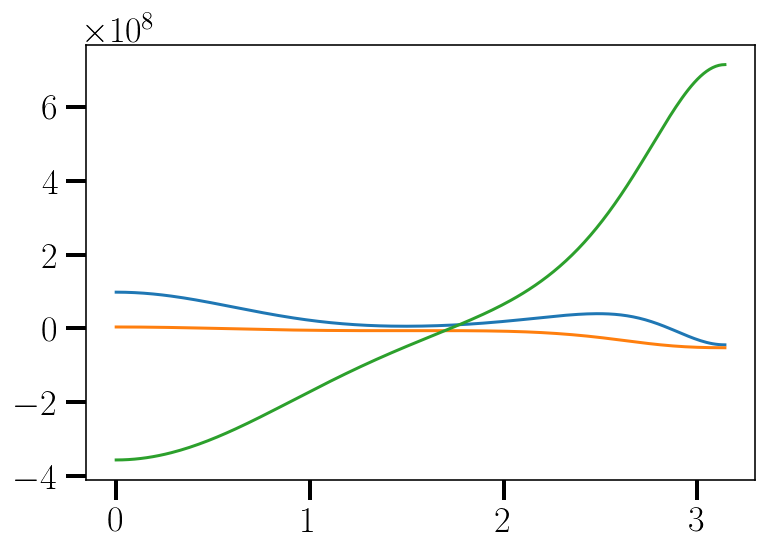

In [17]:
#plot something
r=s=0 # d=x_3

plt.plot(theta,WA1.l1(params,r,s).imag)
plt.plot(theta,RR1.l1(params,derivs,r,s).imag)
plt.plot(theta,GR1.l1(params,betas).imag)